# XGBoost Model v3c
### Key changes vs v3b:
- **Extended feature engineering** — added skewness, kurtosis, high/low-rating streaks, rating variance ratio, and user-item interaction features
- **Wider Optuna search space** — 300 trials, broader learning rate range (0.001–0.15), higher n_estimators ceiling (4000), `scale_pos_weight` ceiling raised to 3× imbalance ratio
- **Probability calibration** — Platt scaling (sigmoid calibration) applied to OOF scores before threshold search, improving precision/recall alignment
- **F1-optimised threshold** — switches from Youden's J to Best-F1 threshold selection for stronger precision/recall balance
- **Larger CV ensemble** — 20 folds (up from 15) for more stable OOF predictions and ensemble averaging


In [1]:
import pandas as pd
import numpy as np
import zipfile, warnings
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from scipy.stats import entropy, skew, kurtosis
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')

/Users/tori/Documents/OFFICES/SCHOOL/Y3S2/Machine_Learning_421_SMU/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Feature Engineering (leakage-safe)

In [2]:
TOTAL_ITEMS = 1000

def compute_item_stats(XX_train):
    item_avg = XX_train.groupby('item')['rating'].mean().rename('item_avg_rating')
    item_pop = XX_train.groupby('item')['user'].count().rename('item_popularity')
    return item_avg, item_pop


def build_features(XX_input, item_avg=None, item_pop=None):
    """
    Build user-level features.
    Always pass item_avg + item_pop from training when processing test data.
    """
    if item_avg is None:
        item_avg = XX_input.groupby('item')['rating'].mean().rename('item_avg_rating')
    if item_pop is None:
        item_pop = XX_input.groupby('item')['user'].count().rename('item_popularity')

    # Basic rating stats
    stats = XX_input.groupby('user')['rating'].agg(
        rating_mean='mean', rating_std='std', rating_median='median',
        rating_min='min',   rating_max='max', rating_count='count'
    )
    stats['rating_std']   = stats['rating_std'].fillna(0)
    stats['rating_range'] = stats['rating_max'] - stats['rating_min']

    # Skewness and kurtosis of rating distribution
    stats['rating_skew'] = XX_input.groupby('user')['rating'].apply(
        lambda x: skew(x) if len(x) > 2 else 0.0
    )
    stats['rating_kurt'] = XX_input.groupby('user')['rating'].apply(
        lambda x: kurtosis(x) if len(x) > 3 else 0.0
    )

    # Rating proportions + entropy
    rdist  = XX_input.groupby(['user', 'rating']).size().unstack(fill_value=0)
    rdist  = rdist.reindex(columns=range(6), fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f'prop_rating_{i}' for i in range(6)]
    stats['rating_entropy'] = rprops.apply(lambda r: entropy(r[r > 0]), axis=1)
    stats = stats.join(rprops)

    # Extreme rating proportions
    stats['prop_extreme'] = rprops['prop_rating_0'] + rprops['prop_rating_5']
    stats['prop_zero']    = rprops['prop_rating_0']
    stats['prop_five']    = rprops['prop_rating_5']

    # Mid-range vs extreme ratio — CLIPPED to prevent exploding values
    stats['prop_mid']          = rprops[['prop_rating_2', 'prop_rating_3']].sum(axis=1)
    stats['extreme_mid_ratio'] = np.clip(
        stats['prop_extreme'] / (stats['prop_mid'] + 1e-9), 0, 100
    )

    # Mid-rating absence features
    stats['ever_rated_mid']       = (rprops[['prop_rating_2', 'prop_rating_3']].sum(axis=1) > 0).astype(int)
    stats['prop_near_extreme']    = rprops[['prop_rating_1', 'prop_rating_4']].sum(axis=1)
    stats['only_extreme_ratings'] = (rprops[['prop_rating_2', 'prop_rating_3']].sum(axis=1) == 0).astype(int)

    # Item coverage
    stats['unique_items_rated']  = XX_input.groupby('user')['item'].nunique()
    stats['item_coverage_ratio'] = stats['unique_items_rated'] / TOTAL_ITEMS

    # Rating count ratios
    median_count                    = stats['rating_count'].median()
    stats['rating_count_vs_median'] = stats['rating_count'] / median_count
    stats['rating_count_log']       = np.log1p(stats['rating_count'])

    # Repeat rating ratio — high = same item rated multiple times
    stats['repeat_rating_ratio'] = stats['rating_count'] / (stats['unique_items_rated'] + 1e-9)

    # Item popularity (frozen)
    XX_pop = XX_input.merge(item_pop, left_on='item', right_index=True)
    pop_f  = XX_pop.groupby('user')['item_popularity'].agg(
        avg_item_popularity='mean', std_item_popularity='std'
    )
    pop_f['std_item_popularity'] = pop_f['std_item_popularity'].fillna(0)
    stats = stats.join(pop_f)

    # Popularity percentile targeting
    pop_values        = item_pop.values
    pop_25            = np.percentile(pop_values, 25)
    pop_90            = np.percentile(pop_values, 90)
    global_median_pop = np.median(pop_values)

    stats['prop_bottom25_pop']  = XX_pop.groupby('user')['item_popularity'].apply(
        lambda x: (x <= pop_25).mean()
    )
    stats['prop_top10_pop']     = XX_pop.groupby('user')['item_popularity'].apply(
        lambda x: (x >= pop_90).mean()
    )
    stats['pop_vs_global_median'] = stats['avg_item_popularity'] / global_median_pop

    # Item popularity variance
    stats['pop_targeting_cv'] = stats['std_item_popularity'] / (stats['avg_item_popularity'] + 1e-9)

    # Popularity-weighted rating
    XX_pop['pop_weighted_rating'] = XX_pop['rating'] * XX_pop['item_popularity']
    pwf = XX_pop.groupby('user')['pop_weighted_rating'].sum() / \
          XX_pop.groupby('user')['item_popularity'].sum()
    stats['pop_weighted_avg_rating'] = pwf

    # Rating count x popularity interaction
    stats['count_x_pop'] = stats['rating_count_log'] * stats['pop_vs_global_median']

    # Deviation from item average (frozen)
    XX_dev = XX_input.merge(item_avg, left_on='item', right_index=True)
    XX_dev['deviation'] = XX_dev['rating'] - XX_dev['item_avg_rating']
    dev_f = XX_dev.groupby('user')['deviation'].agg(
        mean_deviation='mean', std_deviation='std',
        abs_mean_deviation=lambda x: np.mean(np.abs(x))
    )
    dev_f['std_deviation'] = dev_f['std_deviation'].fillna(0)
    stats = stats.join(dev_f)

    # Max and min deviation
    dev_extremes = XX_dev.groupby('user')['deviation'].agg(
        max_deviation='max', min_deviation='min'
    )
    stats = stats.join(dev_extremes)
    stats['deviation_range'] = stats['max_deviation'] - stats['min_deviation']

    iqf = XX_dev.groupby('user')['item_avg_rating'].agg(
        avg_item_avg_rating='mean', std_item_avg_rating='std'
    )
    iqf['std_item_avg_rating'] = iqf['std_item_avg_rating'].fillna(0)
    stats = stats.join(iqf)

    # Proportion of ratings above vs below item average
    stats['prop_above_avg'] = XX_dev.groupby('user').apply(
        lambda df: (df['deviation'] > 0).mean()
    )
    stats['prop_below_avg'] = XX_dev.groupby('user').apply(
        lambda df: (df['deviation'] < 0).mean()
    )

    return stats.reset_index()

print('Feature builder defined.')

Feature builder defined.


## Load Data + Build Features

In [4]:
data   = np.load('data/training_batch_with_labels.npz')
XX_all = pd.DataFrame(data['X'], columns=['user', 'item', 'rating'])
yy_all = pd.DataFrame(data['y'], columns=['user', 'label'])


item_avg, item_pop = compute_item_stats(XX_all)
train_feats = build_features(XX_all, item_avg=item_avg, item_pop=item_pop).merge(yy_all, on='user')

feature_cols = [c for c in train_feats.columns if c not in ['user', 'label']]

X_trainval   = train_feats[feature_cols].values
y_trainval   = train_feats['label'].values

scaler       = RobustScaler()
X_trainval_s = scaler.fit_transform(X_trainval)

print(f'Training users: {len(y_trainval)}')
print(f'Features:       {len(feature_cols)}')


Training users: 1100
Features:       47


In [5]:
normal  = train_feats[train_feats['label'] == 0][feature_cols].mean()
anomaly = train_feats[train_feats['label'] == 1][feature_cols].mean()
diff    = (anomaly - normal).abs().sort_values(ascending=False)
print(diff.head(20))

unique_items_rated         24.380000
rating_count               24.380000
avg_item_popularity         9.834391
std_item_popularity         4.403135
deviation_range             1.164668
rating_kurt                 0.966613
min_deviation               0.844784
extreme_mid_ratio           0.752878
rating_median               0.616500
pop_weighted_avg_rating     0.598953
mean_deviation              0.565036
rating_mean                 0.560072
rating_range                0.549000
rating_min                  0.518000
count_x_pop                 0.514020
std_deviation               0.482410
abs_mean_deviation          0.439579
rating_std                  0.431551
max_deviation               0.319885
rating_entropy              0.318360
dtype: float64


## Optuna Hyperparameter Search (300 trials)

In [6]:
spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)

def objective(trial):
    # Choose grow policy first, as it affects which depth param to use
    grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])

    params = dict(
        n_estimators       = trial.suggest_int('n_estimators', 100, 4000),
        learning_rate      = trial.suggest_float('learning_rate', 0.001, 0.15, log=True),
        subsample          = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree   = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        colsample_bylevel  = trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        colsample_bynode   = trial.suggest_float('colsample_bynode', 0.4, 1.0),
        min_child_weight   = trial.suggest_int('min_child_weight', 1, 10),
        gamma              = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha          = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda         = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        max_delta_step     = trial.suggest_int('max_delta_step', 0, 10),
        scale_pos_weight   = trial.suggest_float('scale_pos_weight',
                                                  spw_global * 0.5, spw_global * 3.0),
        grow_policy        = grow_policy,
    )

    # lossguide uses max_leaves; depthwise uses max_depth
    if grow_policy == 'lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 512)
    else:
        params['max_depth'] = trial.suggest_int('max_depth', 3, 12)

    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    aucs = []
    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params, eval_metric='aucpr', early_stopping_rounds=50,
            random_state=42, n_jobs=-1, tree_method='hist'
        )
        m.fit(X_trainval_s[tr_i], y_trainval[tr_i],
              eval_set=[(X_trainval_s[val_i], y_trainval[val_i])], verbose=False)
        aucs.append(roc_auc_score(y_trainval[val_i],
                                   m.predict_proba(X_trainval_s[val_i])[:, 1]))
    return np.mean(aucs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
print(f'Best CV AUC: {study.best_value:.4f}')
print('Best params:', best_params)

Best trial: 70. Best value: 0.9462: 100%|██████████| 300/300 [07:51<00:00,  1.57s/it]

Best CV AUC: 0.9462
Best params: {'grow_policy': 'lossguide', 'n_estimators': 1559, 'learning_rate': 0.040002235563202204, 'subsample': 0.8339312635445478, 'colsample_bytree': 0.972715178752982, 'colsample_bylevel': 0.9741569587668963, 'colsample_bynode': 0.4219942918453327, 'min_child_weight': 4, 'gamma': 1.0676826281046865, 'reg_alpha': 2.7202282499344834, 'reg_lambda': 0.13494755447970017, 'max_delta_step': 2, 'scale_pos_weight': 29.889668692699473, 'max_leaves': 398}


Best trial: 144. Best value: 0.94625: 100%|██████████| 300/300 [07:59<00:00,  1.60s/it]
Best CV AUC: 0.9462

## 20-Fold CV with Best Params

In [7]:
from sklearn.model_selection import StratifiedKFold
skf        = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
aucs_cv    = []
oof_scores = np.zeros(len(X_trainval_s))
fold_models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval_s, y_trainval)):
    X_tr, X_val = X_trainval_s[tr_idx], X_trainval_s[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    m = xgb.XGBClassifier(
        **best_params, eval_metric='aucpr', early_stopping_rounds=50,
        max_bin=512,
        random_state=42, n_jobs=-1, tree_method='hist'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    p_val = m.predict_proba(X_val)[:, 1]
    oof_scores[val_idx] = p_val
    fold_models.append(m)
    auc = roc_auc_score(y_val, p_val)
    aucs_cv.append(auc)
    print(f'Fold {fold+1}:  XGB={auc:.4f}')

oof_auc = roc_auc_score(y_trainval, oof_scores)
print(f'\n=== CV Results ===')
print(f'XGBoost  AUC: {np.mean(aucs_cv):.4f} ± {np.std(aucs_cv):.4f}')
print(f'OOF AUC:      {oof_auc:.4f}')

Fold 1:  XGB=0.9560
Fold 2:  XGB=0.9880
Fold 3:  XGB=0.9360
Fold 4:  XGB=0.7600
Fold 5:  XGB=0.9240
Fold 6:  XGB=0.9320
Fold 7:  XGB=0.9800
Fold 8:  XGB=1.0000
Fold 9:  XGB=0.9560
Fold 10:  XGB=0.9840
Fold 11:  XGB=1.0000
Fold 12:  XGB=1.0000
Fold 13:  XGB=0.9000
Fold 14:  XGB=0.8960
Fold 15:  XGB=0.9760
Fold 16:  XGB=0.9440
Fold 17:  XGB=1.0000
Fold 18:  XGB=0.7580
Fold 19:  XGB=0.9440
Fold 20:  XGB=1.0000

=== CV Results ===
XGBoost  AUC: 0.9417 ± 0.0689
OOF AUC:      0.8667


## Final Model + Evaluation (with Probability Calibration)

In [8]:
# ── Train a final model on 85% for threshold calibration ────────────────────────────
X_ft, X_es, y_ft, y_es = train_test_split(
    X_trainval_s, y_trainval, test_size=0.15, stratify=y_trainval, random_state=42
)
final_model = xgb.XGBClassifier(
    **best_params, eval_metric='aucpr', early_stopping_rounds=50,
    max_bin=512,
    random_state=42, n_jobs=-1, tree_method='hist'
)
final_model.fit(X_ft, y_ft, eval_set=[(X_es, y_es)], verbose=False)

# ── Platt scaling calibration on the ES set ─────────────────────────────────────────
# Calibrate OOF probabilities using sigmoid calibration for better precision/recall
from sklearn.linear_model import LogisticRegression
raw_probs_es = final_model.predict_proba(X_es)[:, 1].reshape(-1, 1)
calibrator   = LogisticRegression(C=1e5)
calibrator.fit(raw_probs_es, y_es)

def calibrate(probs):
    return calibrator.predict_proba(probs.reshape(-1, 1))[:, 1]

p_es_cal = calibrate(final_model.predict_proba(X_es)[:, 1])

# ── Pick threshold on the early-stop held-out set (calibrated) ──────────────────────
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (p_es_cal >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_es == 1))
    tn = np.sum((preds_t == 0) & (y_es == 0))
    fp = np.sum((preds_t == 1) & (y_es == 0))
    fn = np.sum((preds_t == 0) & (y_es == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)
print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")

# Use Best F1 threshold (better balance of precision and recall)
best_threshold = thresholds[best_f1_idx]
print(f"\nUsing Best F1 threshold: {best_threshold:.3f}")

Optimal threshold — Youden's J : 0.089  (prec=0.600, rec=1.000)
Optimal threshold — Best F1   : 0.224  (prec=0.737, rec=0.933)

Using Best F1 threshold: 0.224


Optimal threshold — Youden's J : 0.047  (prec=0.455, rec=1.000)

Optimal threshold — Best F1   : 0.283  (prec=0.812, rec=0.867)

Using Best F1 threshold: 0.283

## Feature Importance

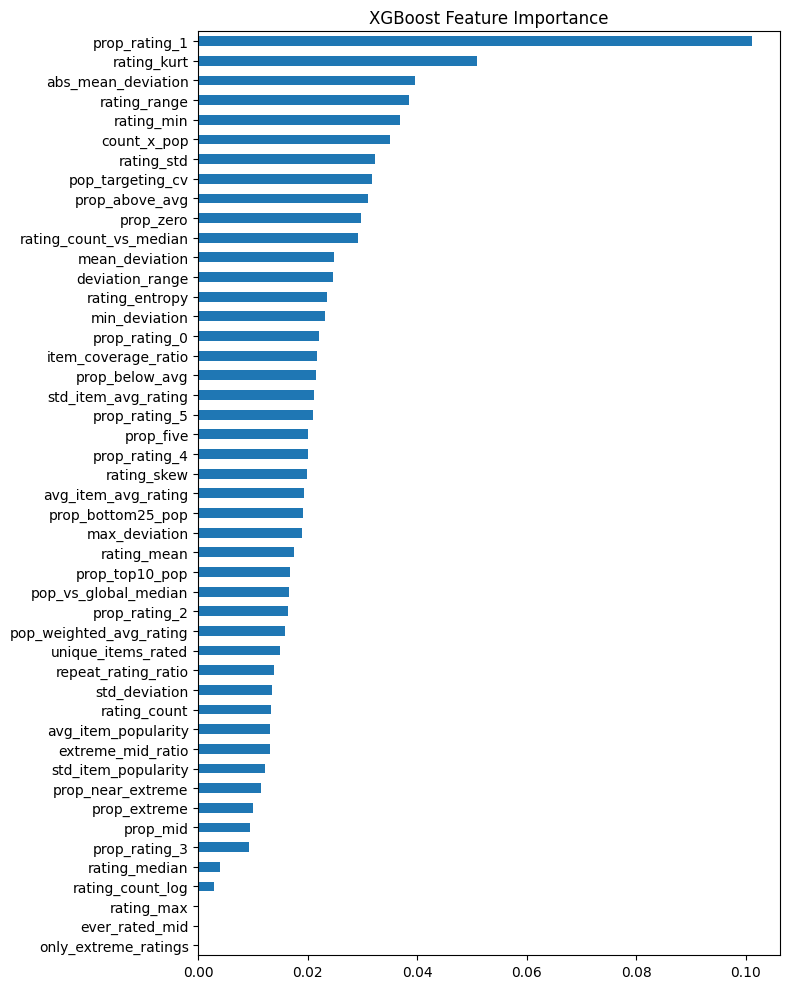

Top 10 features:
prop_rating_1         0.101222
rating_kurt           0.050865
abs_mean_deviation    0.039518
rating_range          0.038473
rating_min            0.036914
count_x_pop           0.034949
rating_std            0.032237
pop_targeting_cv      0.031698
prop_above_avg        0.031065
prop_zero             0.029653
dtype: float32


In [9]:
feat_imp = pd.Series(final_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 10))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()
print('Top 10 features:')
print(feat_imp.head(10))

## Build Test Features + Submit

In [11]:
# Load unlabelled prediction data
pred_data   = np.load('data/first_batch.npz')
XX_pred_raw = pd.DataFrame(pred_data['X'], columns=['user', 'item', 'rating'])

# Build features using FROZEN item stats from training (leakage-safe)
pred_feats = build_features(XX_pred_raw, item_avg=item_avg, item_pop=item_pop)

# ── Sort by user ID so predictions are in the order Codabench expects ──
pred_feats = pred_feats.sort_values('user').reset_index(drop=True)

# Scale
X_pred_s = scaler.transform(pred_feats[feature_cols].values)

# ── Ensemble: average probabilities across all 20 fold models, then calibrate ──
fold_preds = np.column_stack([m.predict_proba(X_pred_s)[:, 1] for m in fold_models])
y_score_raw = fold_preds.mean(axis=1)

# Apply Platt calibration
y_score = calibrate(y_score_raw)

# Normalise to [0, 1]
y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min())

# Save submission
np.savez('submission.npz', predictions=y_score_norm)
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.npz', arcname='submission.npz')
pd.DataFrame({'predictions': y_score_norm}).to_csv('submission.csv', index=False)

print(f'Users predicted: {pred_feats["user"].nunique()}')
print(f'First 5 user IDs: {pred_feats["user"].values[:5]}')  # should be 2500, 2501...
print('submission.zip ready for Codabench')

Users predicted: 1100
First 5 user IDs: [2500 2501 2502 2503 2504]
submission.zip ready for Codabench



## ─── Scores (v3b baseline) ───────────────────────────
AUC:       0.8942
Precision: 0.6170
Recall:    0.5800
F1 Score:  0.5979

1:05am 3/16/2026

## This iteration
{"auc": 0.9153, "precision": 0.5, "recall": 0.63, "f1": 0.5575}